## Linear Regression Pipeline

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import xgboost as xgb

In [20]:
# read train and test dataset
train_set = pd.read_csv('train.csv')
test_set = pd.read_csv('test.csv')

outcome = train_set["BeatsPerMinute"]
features_train = train_set.drop(columns = ["id", "BeatsPerMinute"])

# train and validation split
features_train, features_val, outcome_train, outcome_val = train_test_split(features_train, outcome, test_size=0.1)
print(features_train.shape, features_val.shape, outcome_train.shape, outcome_val.shape)

# a light version of dataset for quick testing of model
features_train_light = features_train[:50000]
features_val_light = features_val[:5000]
outcome_train_light = outcome_train[:50000]
outcome_val_light = outcome_val[:5000]
print(features_train_light.shape, features_val_light.shape, outcome_train_light.shape, outcome_val_light.shape)

(471747, 9) (52417, 9) (471747,) (52417,)
(50000, 9) (5000, 9) (50000,) (5000,)


In [11]:
# fit a linear regression model first
l_model = LinearRegression()
l_model.fit(features_train, outcome_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# make prediction
prediction = l_model.predict(features_val)

# calculate the mean square error and r2 score
mse = mean_squared_error(outcome_val, prediction)
mae = mean_absolute_error(outcome_val, prediction)
r2 = r2_score(outcome_val, prediction)
print(f"The mean squared error is {mse}")
print(f"The mean absolute error is {mae}")
print(f"The r2 score is {r2}")

The mean squared error is 704.9781099262887
The mean absolute error is 21.28333325912349
The r2 score is -7.899178894321679e-06


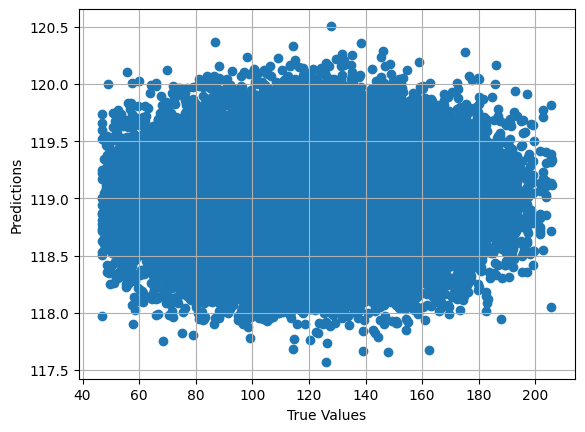

In [16]:
plt.scatter(outcome_val, prediction)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.grid()
plt.show()

In [34]:
# try with a xgboost regressor
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', tree_method = "hist",colsample_bytree = 0.5, learning_rate = 0.05,
                max_depth = 5, alpha = 10, n_estimators = 400, device_type = 'cpu', subsample = 0.8)
xgb_model.fit(features_train, outcome_train)
prediction_xgb = xgb_model.predict(features_val)

c:\Users\tangx\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [18:38:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "device_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
# compute the metrics
mse_xgb = mean_squared_error(outcome_val, prediction_xgb)
mae_xgb = mean_absolute_error(outcome_val, prediction_xgb)
r2_xgb = r2_score(outcome_val, prediction_xgb)
print(f"The mean squared error is {mse_xgb}")
print(f"The mean absolute error is {mae_xgb}")
print(f"The r2 score is {r2_xgb}")

The mean squared error is 696.4455939824879
The mean absolute error is 21.136364028929535
The r2 score is -0.0006022955495192939


In [28]:
# try with a histgradientboosting regressor
hgb_model = HistGradientBoostingRegressor(learning_rate = 0.05, max_iter = 400)
hgb_model.fit(features_train, outcome_train)
prediction_hgb = hgb_model.predict(features_val)

In [29]:
# compute the metrics
mse_hgb = mean_squared_error(outcome_val, prediction_hgb)
mae_hgb = mean_absolute_error(outcome_val, prediction_hgb)
r2_hgb = r2_score(outcome_val, prediction_hgb)
print(f"The mean squared error is {mse_hgb}")
print(f"The mean absolute error is {mae_hgb}")
print(f"The r2 score is {r2_hgb}")

The mean squared error is 695.6040133673748
The mean absolute error is 21.123663020131847
The r2 score is 0.0006068261717581125


In [ ]:
# construct an ensemble pipeline with xgboost and histgradientboosting
